### Objectif

Cette partie vise à :
- Identifier les valeurs manquantes
- Nettoyer les variables (valeurs aberrantes, codes invalides)
- Étudier la distribution de chaque variable individuellement
- Préparer un jeu de données propre pour la modélisation en machine learning

### Importation des bibliothèques et chargement des données

In [2]:

# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Chargement du jeu de données d'apprentissage
train = pd.read_csv(
    'C:/Users/LENOVO/Documents/Stage_DMP/port-ai-project/data/train.csv',
    index_col=0
)

# Vérification de la dimension et aperçu des données
print(train.shape)
print(train.head())
print(train.columns)


(25498, 34)
         Numero_Camion Plaque_Camion ID_Cargaison   Connaissement  \
Statut                                                              
Gate-out    WDJB911D61     DJB911D61  DC240305005               2   
Gate-out  VCH042677500   CH042677500  DC240219002       TABUK0001   
Gate-out  VCH043848864   CH043848864  DC230909091   NSSCB23002351   
Gate-out     WETA18383      ETA18383  DC240224088  HK23170XDBT016   
Gate-out     WETA22810      ETA22810  DC240505007  NJ2401LYGDJ202   

                                   Numero_Marque  Nom_Cargaison   Nom_Navire  \
Statut                                                                         
Gate-out                      MILLINGWHEATINBULK          Wheat  BOS BOUTROS   
Gate-out                       JTMAA7BJ4P4063170        Vehicle  BAHRI TABUK   
Gate-out                       RKLKABAG3P0509459        Vehicle      JIGJIGA   
Gate-out  CCCC-FHECETHIOPIAEAHPROJECTVIADJIBOUTI         *Rebar     HELENA K   
Gate-out          BELTCO

In [4]:
train.head()

,Numero_Camion,Plaque_Camion,ID_Cargaison,Connaissement,Numero_Marque,Nom_Cargaison,Nom_Navire,Voyage,Poids_Brut_Camion_kg,Poids_Tare_kg,...,IP_Sortie,Poids_Camion_Sortie_kg,Operateur_Sortie,Type_Travail,Routine_Manutention,Numero_Sequence,Remarque,Annule,Annule_Par,Date_Annulation
Statut,,,,,,,,,,,,,,,,,,,,,
Gate-out,WDJB911D61,DJB911D61,DC240305005,2,MILLINGWHEATINBULK,Wheat,BOS BOUTROS,12024,51800.0,16740.0,...,NaN,51800.0,AHMED.ALI,Direct Discharge,NaN,NaN,NaN,NaN,NaN,NaN
Gate-out,VCH042677500,CH042677500,DC240219002,TABUK0001,JTMAA7BJ4P4063170,Vehicle,BAHRI TABUK,26,2560.0,0.0,...,NaN,0.0,MIGUIL.ALI,Receiving,NaN,NaN,NaN,NaN,NaN,NaN
Gate-out,VCH043848864,CH043848864,DC230909091,NSSCB23002351,RKLKABAG3P0509459,Vehicle,JIGJIGA,46WB,1200.0,1200.0,...,NaN,1200.0,BADOUL.MOHAMED,Delivery,NaN,NaN,NaN,NaN,NaN,NaN
Gate-out,WETA18383,ETA18383,DC240224088,HK23170XDBT016,CCCC-FHECETHIOPIAEAHPROJECTVIADJIBOUTI,*Rebar,HELENA K,23170,63320.0,19660.0,...,NaN,63320.0,AWALEH.IBRAHIM,Delivery,NaN,NaN,NaN,NaN,NaN,NaN
Gate-out,WETA22810,ETA22810,DC240505007,NJ2401LYGDJ202,BELTCONVEYORCURVEDBELTCONVEYOR,General Cargo,NASCO JADE,2401,20000.0,1000.0,...,NaN,20000.0,ABDOURAHMAN ALI HASSAN,Delivery,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train.describe

<bound method NDFrame.describe of          Numero_Camion Plaque_Camion ID_Cargaison       Connaissement  \
Statut                                                                  
Gate-out    WDJB911D61     DJB911D61  DC240305005                   2   
Gate-out  VCH042677500   CH042677500  DC240219002           TABUK0001   
Gate-out  VCH043848864   CH043848864  DC230909091       NSSCB23002351   
Gate-out     WETA18383      ETA18383  DC240224088      HK23170XDBT016   
Gate-out     WETA22810      ETA22810  DC240505007      NJ2401LYGDJ202   
...                ...           ...          ...                 ...   
Gate-out  VCH042736204   CH042736204  DC240216024  PJ23168LDBT013B017   
Gate-out     WETA21421      ETA21421  DC240408002       PENCB24002428   
Gate-out    WDJB677D64     DJB677D64  DC240318014       SSMCB24000011   
Gate-out      WET51386       ET51386  DC240114020       SSMCB24000002   
Gate-out    WDJB785D66     DJB785D66  DC230910001                   1   

                

### Doublons

In [6]:
# ── Doublons ──────────────────────────────────────────
print("Nombre de doublons :", train.duplicated().sum())
train = train.drop_duplicates()
print("Après suppression   :", train.shape)

# ── Valeurs manquantes ────────────────────────────────
print("\nValeurs manquantes :")
print(train.isnull().sum()[train.isnull().sum() > 0])

# ── Supprimer les lignes sans variable cible ──────────
train.dropna(subset=['Surestarie_min'], inplace=True)
print("\nDataset propre final :", train.shape)

Nombre de doublons : 0
Après suppression   : (25498, 34)

Valeurs manquantes :
Poids_Brut_Camion_kg          18
Poids_Tare_kg                 18
Poids_Cargaison_kg          3349
Numero_Conteneur_Entree    25498
Salle_Balance_Entree       25498
Region_Entree              25498
IP_Entree                  25498
Poids_Camion_Entree_kg      3333
Numero_Conteneur_Sortie    25498
ID_Balance_Sortie          25498
Region_Sortie              25498
IP_Sortie                  25498
Poids_Camion_Sortie_kg        18
Routine_Manutention        25498
Numero_Sequence            25498
Remarque                   25498
Annule                     25498
Annule_Par                 25498
Date_Annulation            25498
dtype: int64

Dataset propre final : (25498, 34)


la Dataset contient aucune valeur manquante 

### Étude des valeurs manquantes par variable

Numero_Camion                  0
Plaque_Camion                  0
ID_Cargaison                   0
Connaissement                  0
Numero_Marque                  0
Nom_Cargaison                  0
Nom_Navire                     0
Voyage                         0
Poids_Brut_Camion_kg          18
Poids_Tare_kg                 18
Poids_Cargaison_kg          3349
Heure_Entree_Gate              0
Heure_Sortie_Gate              0
Surestarie_min                 0
Numero_Pesee                   0
Numero_Conteneur_Entree    25498
Salle_Balance_Entree       25498
Region_Entree              25498
IP_Entree                  25498
Poids_Camion_Entree_kg      3333
Operateur_Entree               0
Numero_Conteneur_Sortie    25498
ID_Balance_Sortie          25498
Region_Sortie              25498
IP_Sortie                  25498
Poids_Camion_Sortie_kg        18
Operateur_Sortie               0
Type_Travail                   0
Routine_Manutention        25498
Numero_Sequence            25498
Remarque  

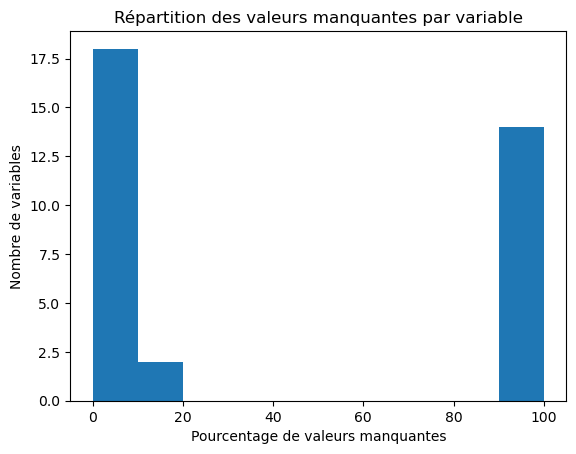

In [7]:
#etude des valeurs manquantes
#sur les variables
# Nombre de valeurs manquantes par variable
val_manq_var = train.isnull().sum()
print(val_manq_var)

# Pourcentage de valeurs manquantes par variable
val_manq_var2 = train.isnull().mean() * 100
print(val_manq_var2)

# Histogramme du pourcentage de valeurs manquantes
plt.hist(val_manq_var2)
plt.xlabel("Pourcentage de valeurs manquantes")
plt.ylabel("Nombre de variables")
plt.title("Répartition des valeurs manquantes par variable")
plt.show()

### Suppression des variables avec plus de 50 % de valeurs manquantes

In [8]:

cols_to_drop = [
    'Numero_Conteneur_Entree', 'Salle_Balance_Entree', 'Region_Entree', 'IP_Entree',
    'Numero_Conteneur_Sortie', 'ID_Balance_Sortie', 'Region_Sortie', 'IP_Sortie',
    'Routine_Manutention', 'Numero_Sequence', 'Remarque', 'Annule', 'Annule_Par', 'Date_Annulation'
]

train = train.drop(columns=cols_to_drop)


print(" Colonnes supprimées :", len(cols_to_drop))
print(" Train :", train.shape)

 Colonnes supprimées : 14
 Train : (25498, 20)


L'analyse des valeurs manquantes révèle trois groupes :
Variables complètes (0%) : Surestarie_min (variable cible), Heure_Entree_Gate, Type_Travail, etc.
Variables partiellement manquantes (< 15%) : Poids_Cargaison_kg (13.13%), Poids_Camion_Entree_kg (13.07%), Poids_Brut_Camion_kg (0.07%)
Variables entièrement manquantes (100%) : Numero_Conteneur_Entree/Sortie, Region, IP, Remarque, etc.
Ces dernières seront supprimées à l'étape suivante.
Les valeurs partiellement manquantes seront traitées ultérieurement par des méthodes d'imputation.

### Transformation logarithmique

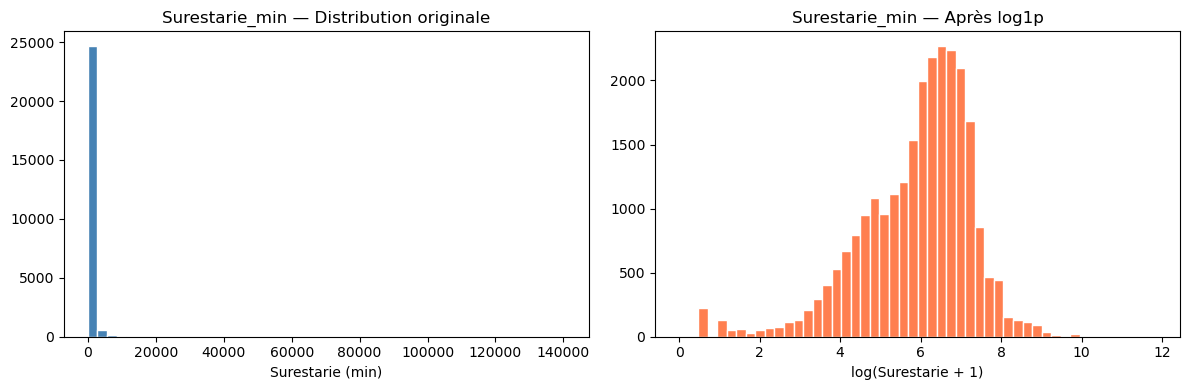

Skewness original  : 40.94312639837206
Skewness après log : -0.9985644181745662


In [9]:
# Visualiser la distribution de Surestarie_min
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Avant transformation
axes[0].hist(train['Surestarie_min'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Surestarie_min — Distribution originale')
axes[0].set_xlabel('Surestarie (min)')

# Après transformation log
axes[1].hist(np.log1p(train['Surestarie_min']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Surestarie_min — Après log1p')
axes[1].set_xlabel('log(Surestarie + 1)')

plt.tight_layout()
plt.show()

# Vérifier l'asymétrie (skewness)
print("Skewness original  :", train['Surestarie_min'].skew())
print("Skewness après log :", np.log1p(train['Surestarie_min']).skew())

 La distribution originale de Surestarie_min est fortement asymétrique à droite
(skewness élevé) avec la majorité des valeurs concentrées près de zéro
et quelques valeurs extrêmes allant jusqu'à 140 000 min.
La transformation logarithmique (log1p) corrige cette asymétrie et produit
une distribution proche d'une loi normale — ce qui améliore les performances
des modèles ML sensibles à la distribution des variables.

In [10]:
# La variable Surestarie_min présente une forte asymétrie à droite.
# On applique log1p = log(1+x) pour gérer les valeurs zéro
# et normaliser la distribution avant la modélisation.

# Variables sur lesquelles appliquer le log
log_vars = ['Surestarie_min', 'Poids_Brut_Camion_kg', 'Poids_Tare_kg', 
            'Poids_Cargaison_kg', 'Poids_Camion_Sortie_kg']

# Création des colonnes log-transformées
for var in log_vars:
    train[f'log_{var}'] = np.log1p(train[var])


# Vérification
print(train[log_vars + [f'log_{v}' for v in log_vars]].head())

          Surestarie_min  Poids_Brut_Camion_kg  Poids_Tare_kg  \
Statut                                                          
Gate-out             106               51800.0        16740.0   
Gate-out             100                2560.0            0.0   
Gate-out            4280                1200.0         1200.0   
Gate-out             429               63320.0        19660.0   
Gate-out               1               20000.0         1000.0   

          Poids_Cargaison_kg  Poids_Camion_Sortie_kg  log_Surestarie_min  \
Statut                                                                     
Gate-out             34990.0                 51800.0            4.672829   
Gate-out              2560.0                     0.0            4.615121   
Gate-out                 NaN                  1200.0            8.361942   
Gate-out             43660.0                 63320.0            6.063785   
Gate-out             19000.0                 20000.0            0.693147   

          l

### Séparation des variables qualitatives et quantitatives

In [11]:
# Listes des variables selon leur type
var_quanti = [
    'Poids_Brut_Camion_kg',
    'Poids_Tare_kg',
    'Poids_Cargaison_kg',
    'Poids_Camion_Entree_kg',
    'Poids_Camion_Sortie_kg',
    'Surestarie_min',
    'log_Surestarie_min',
    'log_Poids_Brut_Camion_kg',
    'log_Poids_Tare_kg',
    'log_Poids_Cargaison_kg',
    'log_Poids_Camion_Sortie_kg'
]

var_quali = [
    'Nom_Cargaison',
    'Nom_Navire',
    'Operateur_Entree',
    'Operateur_Sortie',
    'Type_Travail'
]

### Analyse univariée des variables quantitatives

=== Analyse de Poids_Brut_Camion_kg ===
count    2.548000e+04
mean     6.747315e+04
std      1.959736e+06
min      0.000000e+00
25%      4.317500e+04
50%      6.204000e+04
75%      6.622000e+04
max      2.404040e+08
Name: Poids_Brut_Camion_kg, dtype: float64


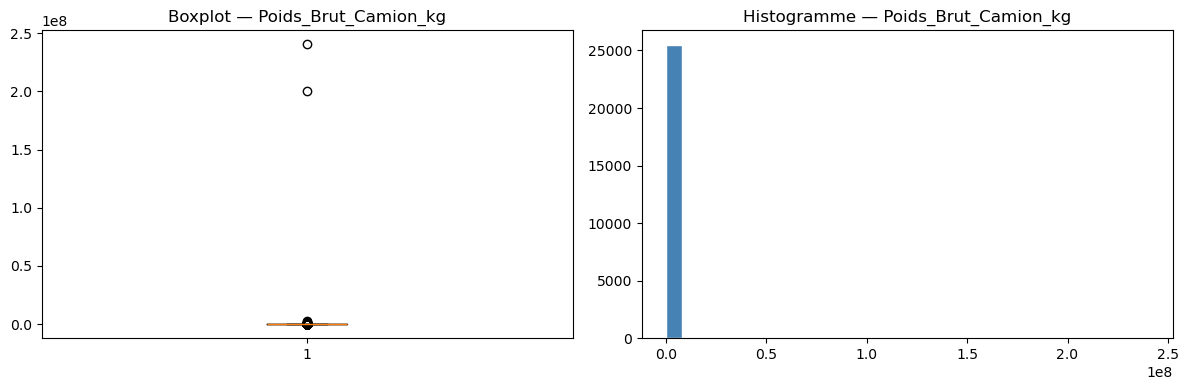

=== Analyse de Poids_Tare_kg ===
count    25480.000000
mean     16706.612206
std       7685.365622
min          0.000000
25%      17000.000000
50%      19575.000000
75%      21140.000000
max      97200.000000
Name: Poids_Tare_kg, dtype: float64


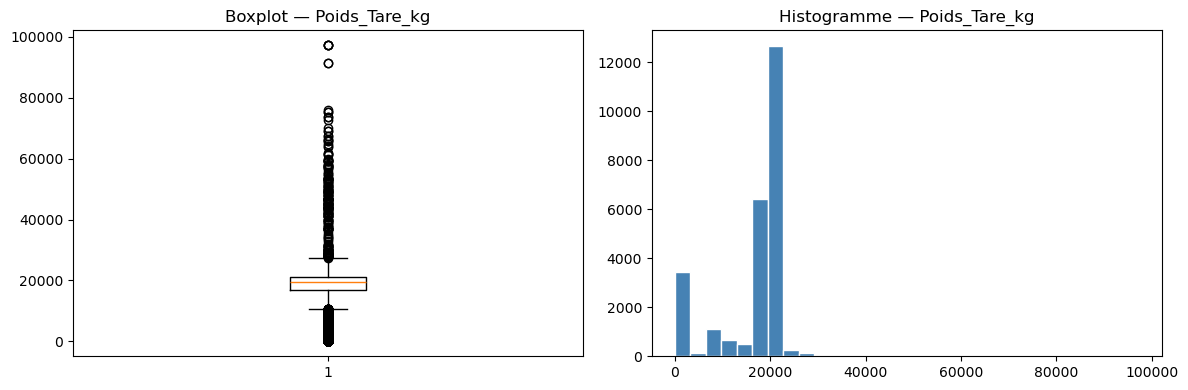

=== Analyse de Poids_Cargaison_kg ===
count    2.214900e+04
mean     5.826202e+04
std      2.101768e+06
min      0.000000e+00
25%      3.507000e+04
50%      4.210800e+04
75%      4.493000e+04
max      2.403870e+08
Name: Poids_Cargaison_kg, dtype: float64


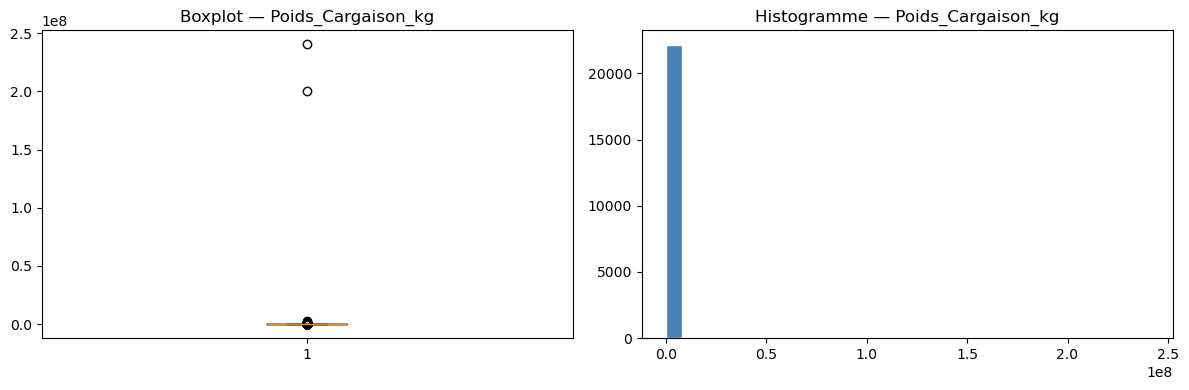

=== Analyse de Poids_Camion_Entree_kg ===
count    22165.000000
mean     18353.302775
std       6499.464967
min          0.000000
25%      17840.000000
50%      20160.000000
75%      21300.000000
max      88302.000000
Name: Poids_Camion_Entree_kg, dtype: float64


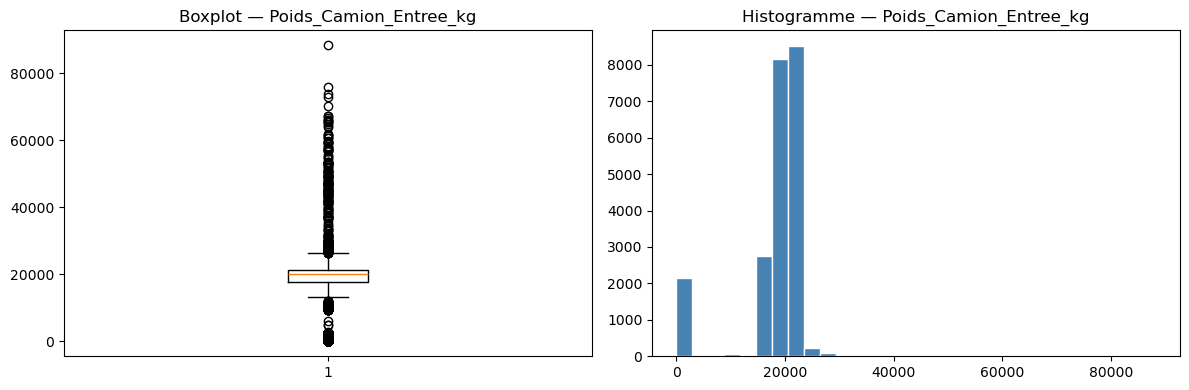

=== Analyse de Poids_Camion_Sortie_kg ===
count    2.548000e+04
mean     6.724616e+04
std      1.959743e+06
min      0.000000e+00
25%      4.268000e+04
50%      6.202000e+04
75%      6.622000e+04
max      2.404040e+08
Name: Poids_Camion_Sortie_kg, dtype: float64


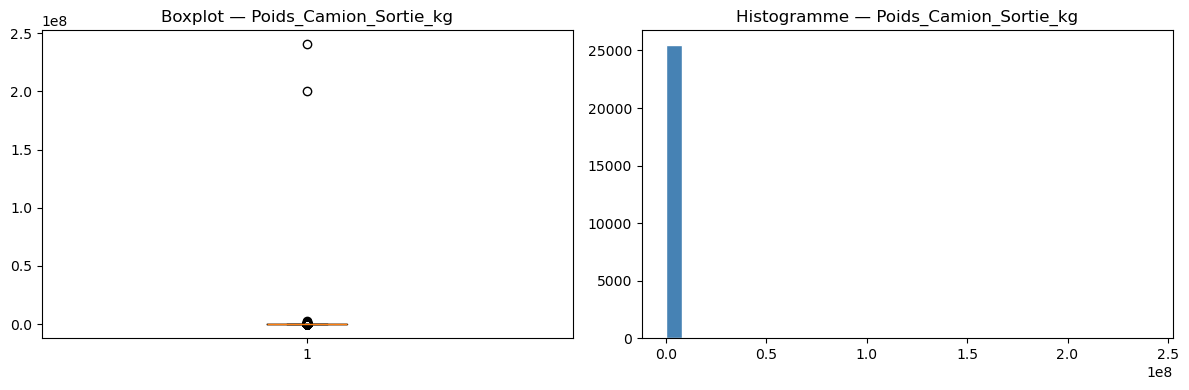

=== Analyse de Surestarie_min ===
count     25498.000000
mean        766.810260
std        1983.003134
min           0.000000
25%         164.000000
50%         478.000000
75%         944.000000
max      140473.000000
Name: Surestarie_min, dtype: float64


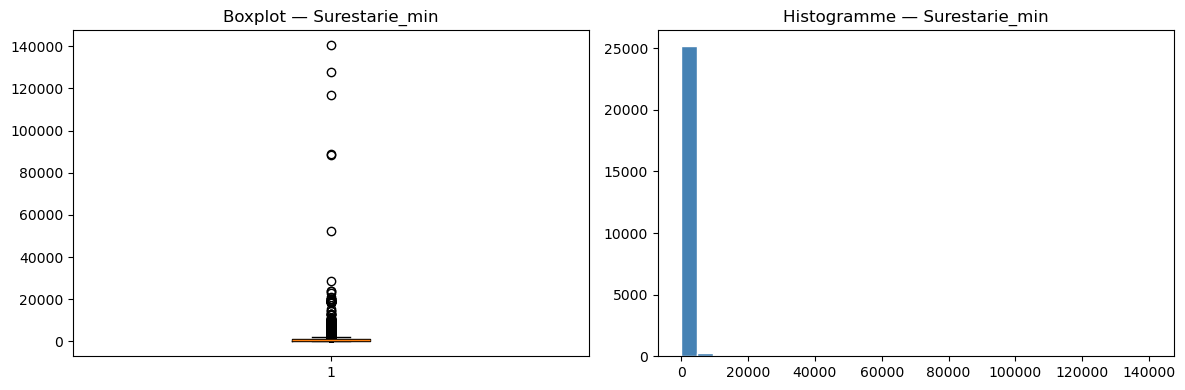

=== Analyse de log_Surestarie_min ===
count    25498.000000
mean         5.894275
std          1.403906
min          0.000000
25%          5.105945
50%          6.171701
75%          6.851185
max         11.852778
Name: log_Surestarie_min, dtype: float64


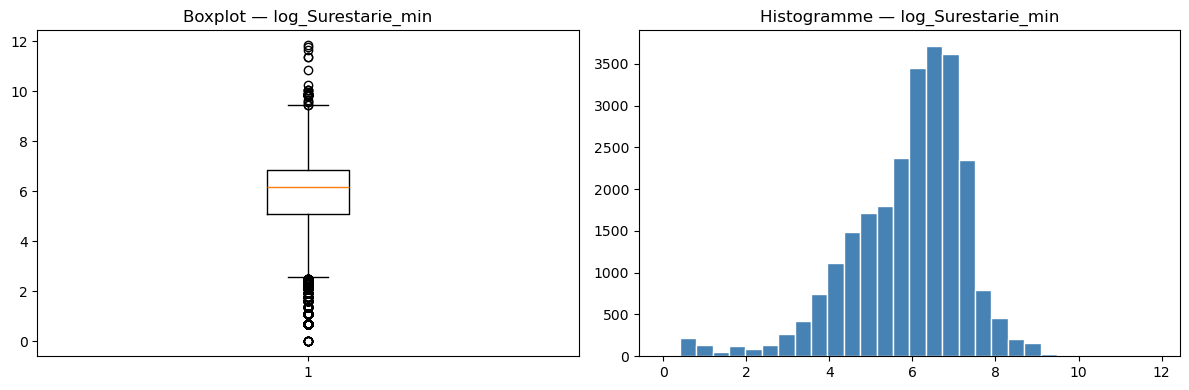

=== Analyse de log_Poids_Brut_Camion_kg ===
count    25480.000000
mean        10.432625
std          1.275531
min          0.000000
25%         10.673040
50%         11.035551
75%         11.100753
max         19.297831
Name: log_Poids_Brut_Camion_kg, dtype: float64


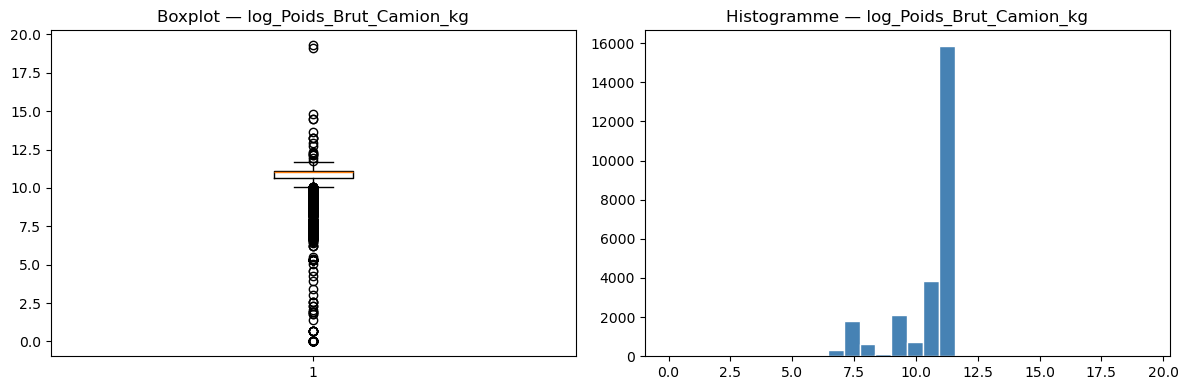

=== Analyse de log_Poids_Tare_kg ===
count    25480.000000
mean         8.918948
std          2.675530
min          0.000000
25%          9.741027
50%          9.882060
75%          9.958970
max         11.484536
Name: log_Poids_Tare_kg, dtype: float64


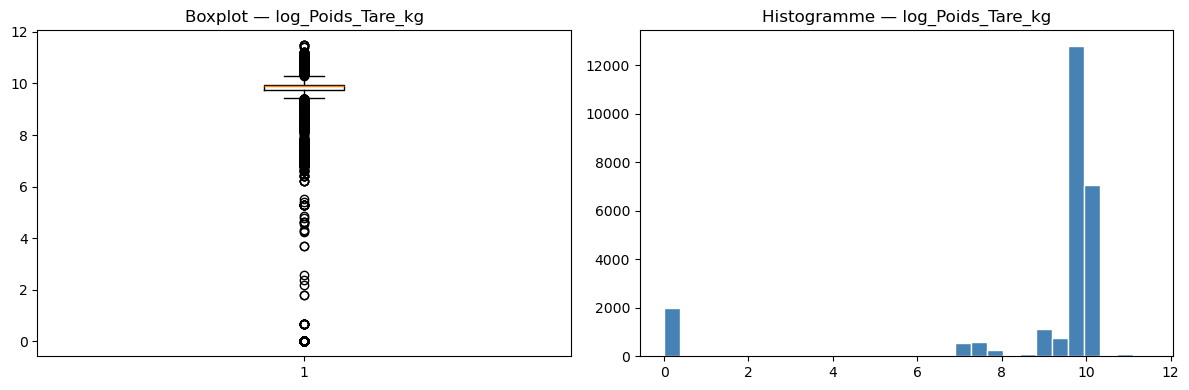

=== Analyse de log_Poids_Cargaison_kg ===
count    22149.000000
mean        10.330363
std          0.993864
min          0.000000
25%         10.465130
50%         10.648017
75%         10.712883
max         19.297761
Name: log_Poids_Cargaison_kg, dtype: float64


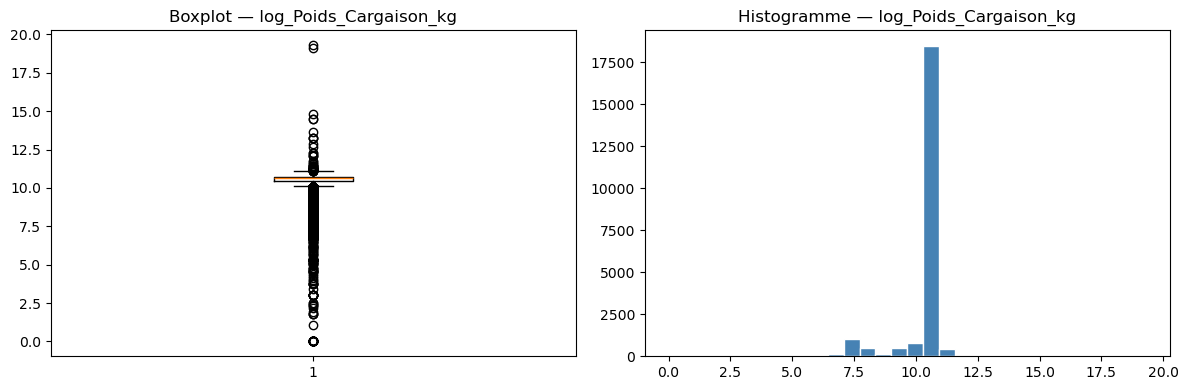

=== Analyse de log_Poids_Camion_Sortie_kg ===
count    25480.000000
mean        10.107938
std          2.380872
min          0.000000
25%         10.661508
50%         11.035228
75%         11.100753
max         19.297831
Name: log_Poids_Camion_Sortie_kg, dtype: float64


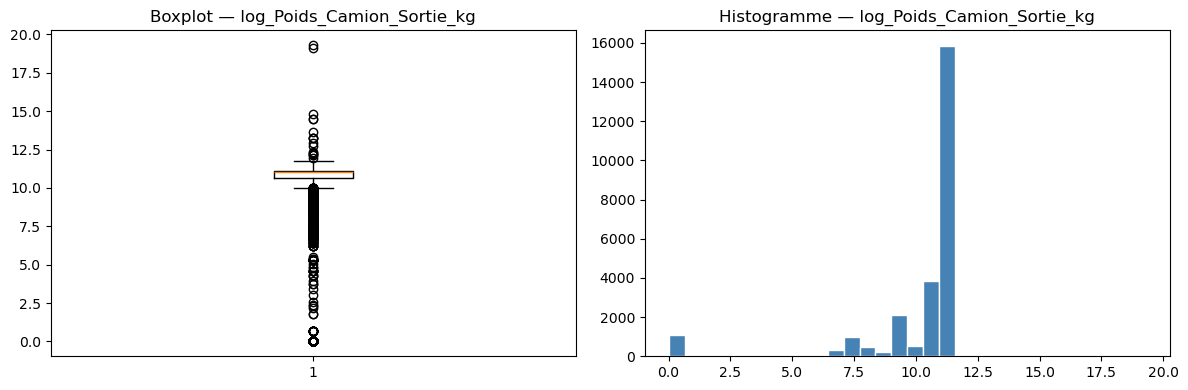

In [12]:
def uniquan(var, df, log_transform=False):
    """
    Affiche describe, boxplot et histogramme pour une variable quantitative.
    Si log_transform=True, affiche la distribution log-transformée.
    """
    if log_transform:
        data = np.log1p(df[var])
        titre = f"log_{var}"
    else:
        data = df[var]
        titre = var

    print(f"=== Analyse de {titre} ===")
    print(data.describe())

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.boxplot(data.dropna())
    plt.title(f"Boxplot — {titre}")

    plt.subplot(1, 2, 2)
    plt.hist(data.dropna(), bins=30, color='steelblue', edgecolor='white')
    plt.title(f"Histogramme — {titre}")

    plt.tight_layout()
    plt.show()

# Application sur toutes les variables quantitatives
for var in var_quanti:
    uniquan(var, train)

### Traitement des valeurs aberrantes (variables quantitatives)

In [14]:
# Remplacement des valeurs aberrantes par NaN
train.loc[train['Poids_Brut_Camion_kg'] > 100000, 'Poids_Brut_Camion_kg'] = np.nan
train.loc[train['Poids_Cargaison_kg'] > 100000, 'Poids_Cargaison_kg'] = np.nan
train.loc[train['Poids_Camion_Sortie_kg'] > 100000, 'Poids_Camion_Sortie_kg'] = np.nan
train.loc[train['Poids_Tare_kg'] > 100000, 'Poids_Tare_kg'] = np.nan
train.loc[train['Poids_Camion_Entree_kg'] > 100000, 'Poids_Camion_Entree_kg'] = np.nan
train.loc[train['Surestarie_min'] > 140000, 'Surestarie_min'] = np.nan
train.loc[train['Surestarie_min'] < 0, 'Surestarie_min'] = np.nan

In [15]:
essai=train[var_quanti].describe()
print(essai.iloc[:,0:10])
print(essai.iloc[:,10:20])

       Poids_Brut_Camion_kg  Poids_Tare_kg  Poids_Cargaison_kg  \
count          25455.000000   25480.000000        22129.000000   
mean           49753.612493   16706.612206        37896.361471   
std            24021.073236    7685.365622        13405.067189   
min                0.000000       0.000000            0.000000   
25%            42880.000000   17000.000000        35060.000000   
50%            62020.000000   19575.000000        42108.000000   
75%            66220.000000   21140.000000        44930.000000   
max            98200.000000   97200.000000        92100.000000   

       Poids_Camion_Entree_kg  Poids_Camion_Sortie_kg  Surestarie_min  \
count            22165.000000            25455.000000    25497.000000   
mean             18353.302775            49526.392025      761.330941   
std               6499.464967            24387.511764     1779.578846   
min                  0.000000                0.000000        0.000000   
25%              17840.000000           

In [16]:
# Vérification après nettoyage
train[var_quanti].describe()


,Poids_Brut_Camion_kg,Poids_Tare_kg,Poids_Cargaison_kg,Poids_Camion_Entree_kg,Poids_Camion_Sortie_kg,Surestarie_min,log_Surestarie_min,log_Poids_Brut_Camion_kg,log_Poids_Tare_kg,log_Poids_Cargaison_kg,log_Poids_Camion_Sortie_kg
count,25455.000000,25480.000000,22129.000000,22165.000000,25455.000000,25497.000000,25498.000000,25480.000000,25480.000000,22149.000000,25480.000000
mean,49753.612493,16706.612206,37896.361471,18353.302775,49526.392025,761.330941,5.894275,10.432625,8.918948,10.330363,10.107938
std,24021.073236,7685.365622,13405.067189,6499.464967,24387.511764,1779.578846,1.403906,1.275531,2.675530,0.993864,2.380872
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42880.000000,17000.000000,35060.000000,17840.000000,42230.000000,164.000000,5.105945,10.673040,9.741027,10.465130,10.661508
50%,62020.000000,19575.000000,42108.000000,20160.000000,62020.000000,478.000000,6.171701,11.035551,9.882060,10.648017,11.035228
75%,66220.000000,21140.000000,44930.000000,21300.000000,66220.000000,944.000000,6.851185,11.100753,9.958970,10.712883,11.100753
max,98200.000000,97200.000000,92100.000000,88302.000000,98200.000000,127953.000000,11.852778,19.297831,11.484536,19.297761,19.297831


=== Analyse de Poids_Brut_Camion_kg ===
count    25455.000000
mean     49753.612493
std      24021.073236
min          0.000000
25%      42880.000000
50%      62020.000000
75%      66220.000000
max      98200.000000
Name: Poids_Brut_Camion_kg, dtype: float64


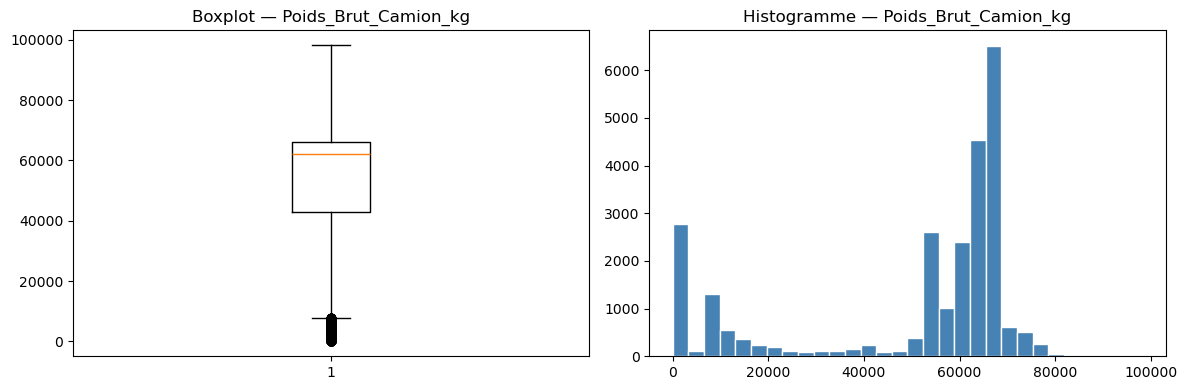

=== Analyse de Poids_Tare_kg ===
count    25480.000000
mean     16706.612206
std       7685.365622
min          0.000000
25%      17000.000000
50%      19575.000000
75%      21140.000000
max      97200.000000
Name: Poids_Tare_kg, dtype: float64


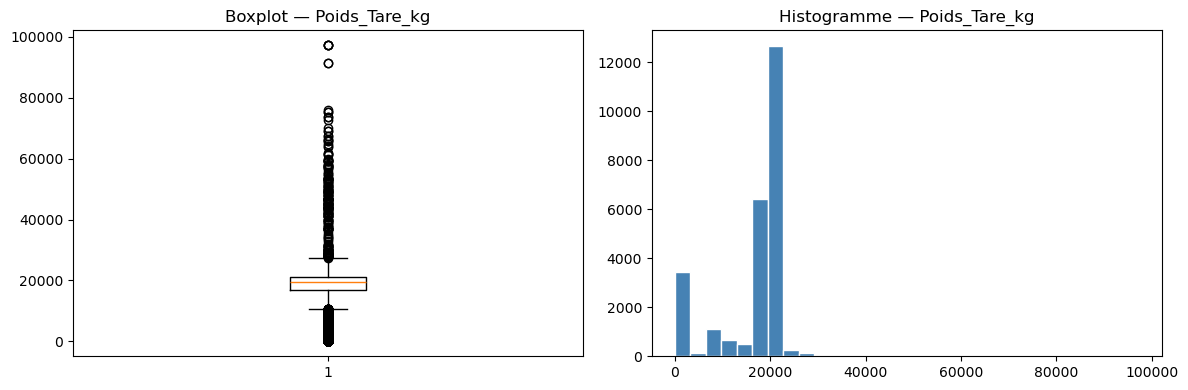

=== Analyse de Poids_Cargaison_kg ===
count    22129.000000
mean     37896.361471
std      13405.067189
min          0.000000
25%      35060.000000
50%      42108.000000
75%      44930.000000
max      92100.000000
Name: Poids_Cargaison_kg, dtype: float64


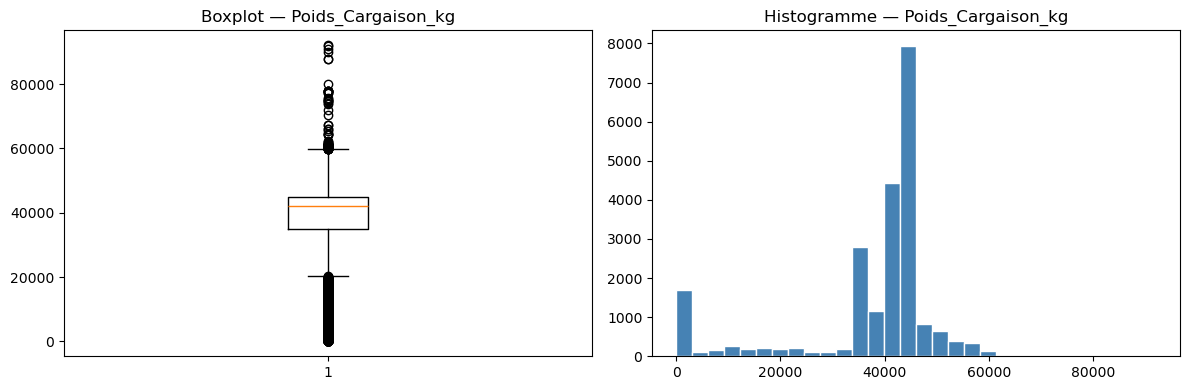

=== Analyse de Poids_Camion_Entree_kg ===
count    22165.000000
mean     18353.302775
std       6499.464967
min          0.000000
25%      17840.000000
50%      20160.000000
75%      21300.000000
max      88302.000000
Name: Poids_Camion_Entree_kg, dtype: float64


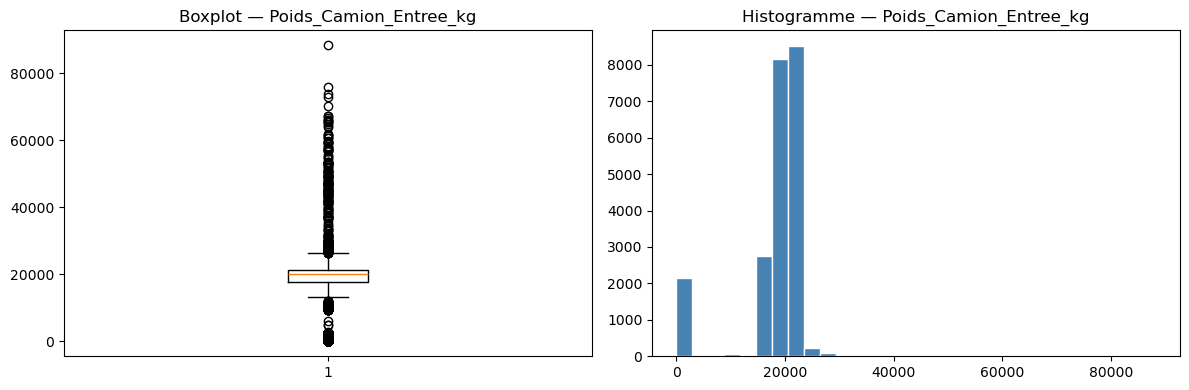

=== Analyse de Poids_Camion_Sortie_kg ===
count    25455.000000
mean     49526.392025
std      24387.511764
min          0.000000
25%      42230.000000
50%      62020.000000
75%      66220.000000
max      98200.000000
Name: Poids_Camion_Sortie_kg, dtype: float64


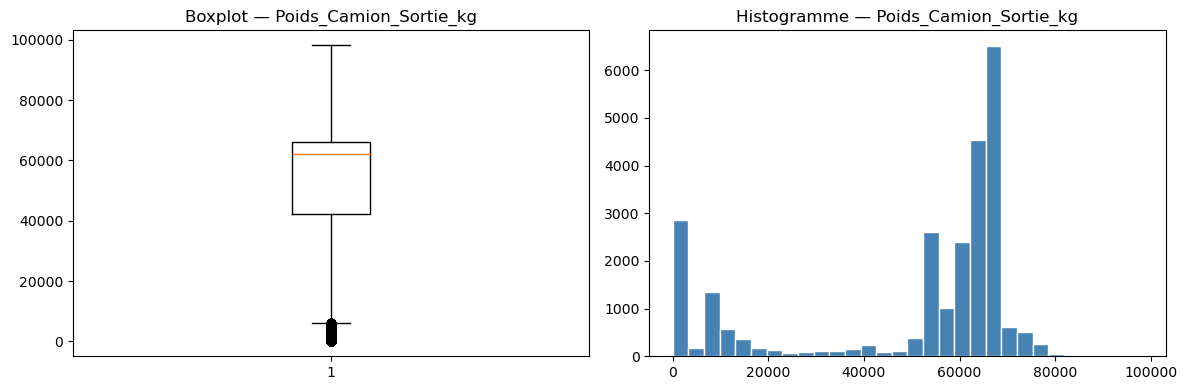

=== Analyse de Surestarie_min ===
count     25497.000000
mean        761.330941
std        1779.578846
min           0.000000
25%         164.000000
50%         478.000000
75%         944.000000
max      127953.000000
Name: Surestarie_min, dtype: float64


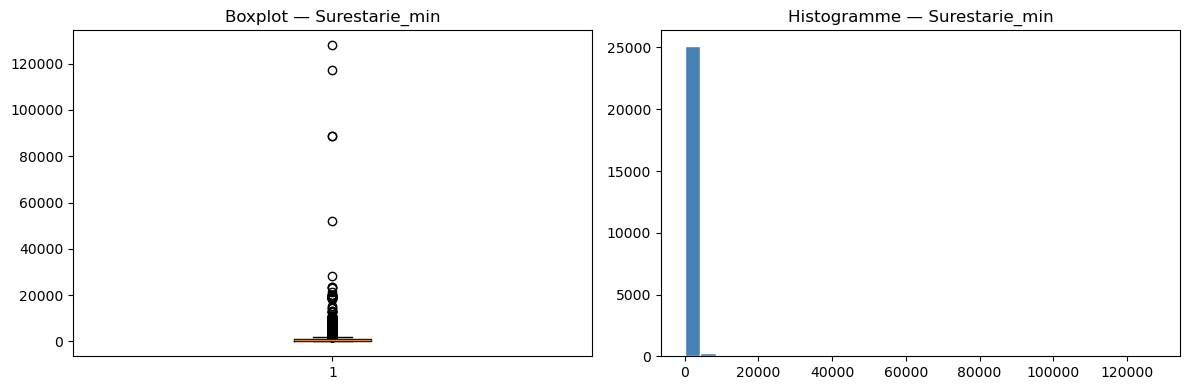

=== Analyse de log_Surestarie_min ===
count    25498.000000
mean         5.894275
std          1.403906
min          0.000000
25%          5.105945
50%          6.171701
75%          6.851185
max         11.852778
Name: log_Surestarie_min, dtype: float64


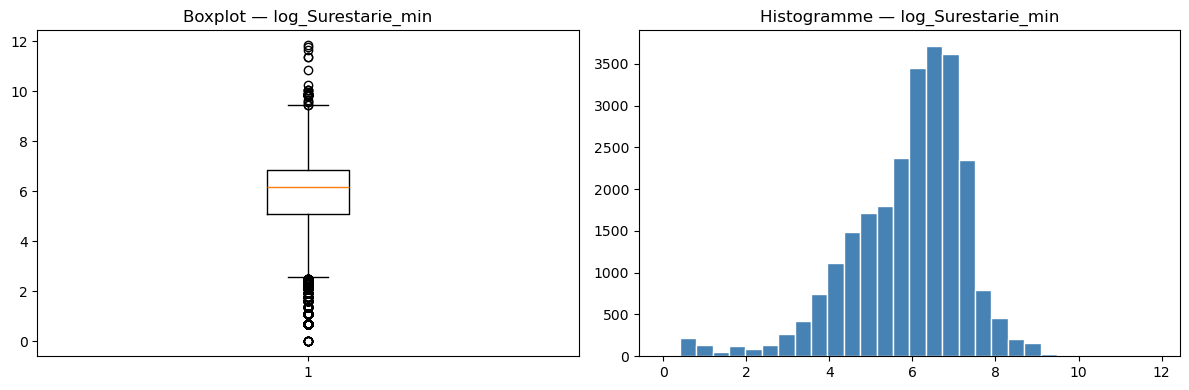

=== Analyse de log_Poids_Brut_Camion_kg ===
count    25480.000000
mean        10.432625
std          1.275531
min          0.000000
25%         10.673040
50%         11.035551
75%         11.100753
max         19.297831
Name: log_Poids_Brut_Camion_kg, dtype: float64


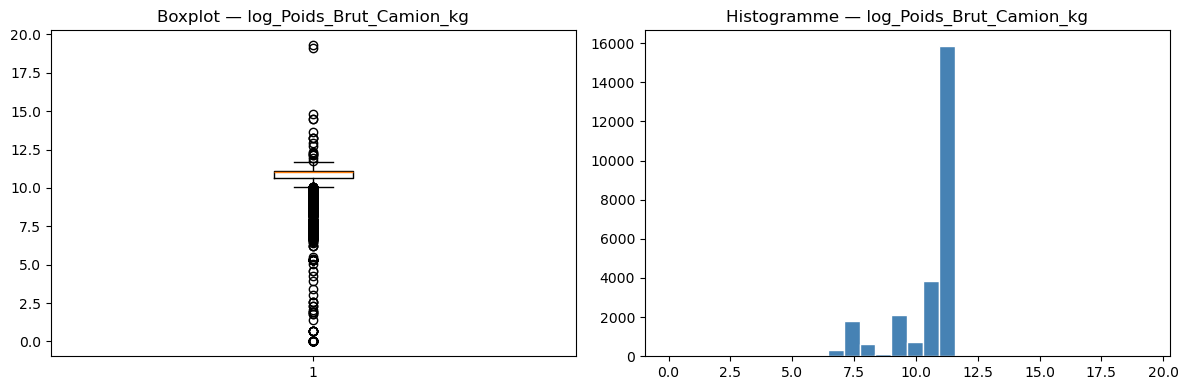

=== Analyse de log_Poids_Tare_kg ===
count    25480.000000
mean         8.918948
std          2.675530
min          0.000000
25%          9.741027
50%          9.882060
75%          9.958970
max         11.484536
Name: log_Poids_Tare_kg, dtype: float64


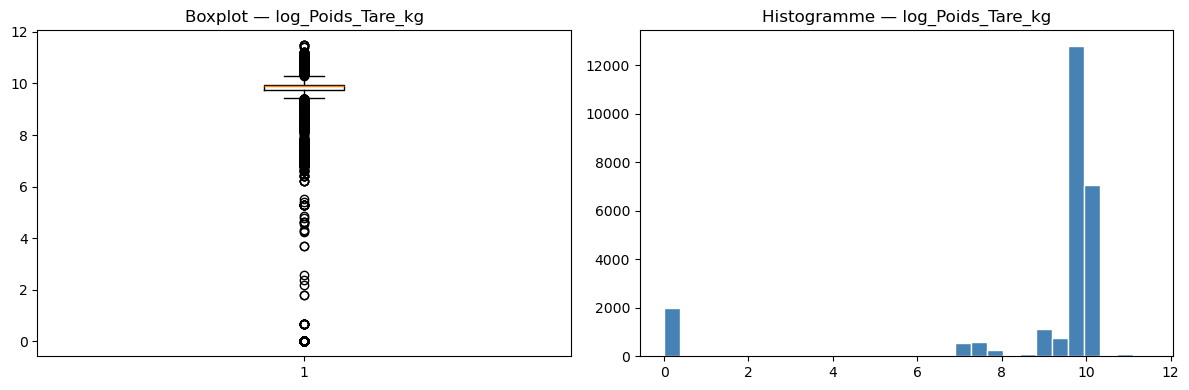

=== Analyse de log_Poids_Cargaison_kg ===
count    22149.000000
mean        10.330363
std          0.993864
min          0.000000
25%         10.465130
50%         10.648017
75%         10.712883
max         19.297761
Name: log_Poids_Cargaison_kg, dtype: float64


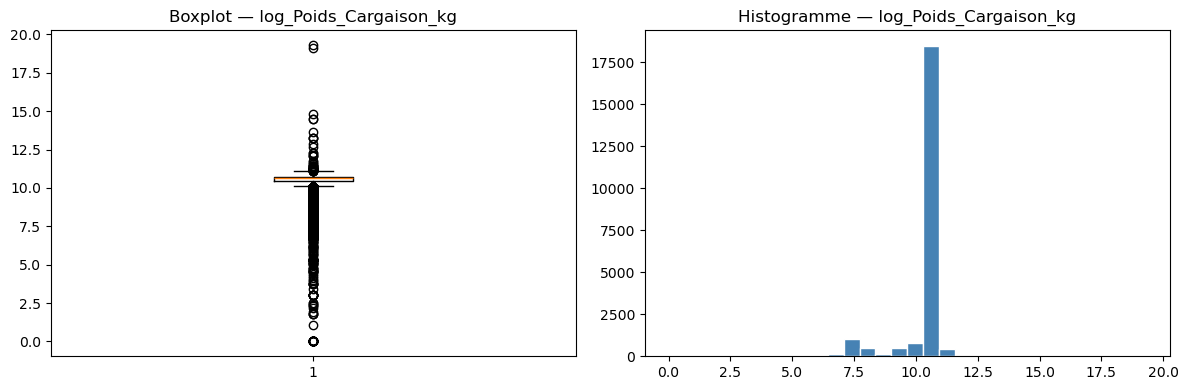

=== Analyse de log_Poids_Camion_Sortie_kg ===
count    25480.000000
mean        10.107938
std          2.380872
min          0.000000
25%         10.661508
50%         11.035228
75%         11.100753
max         19.297831
Name: log_Poids_Camion_Sortie_kg, dtype: float64


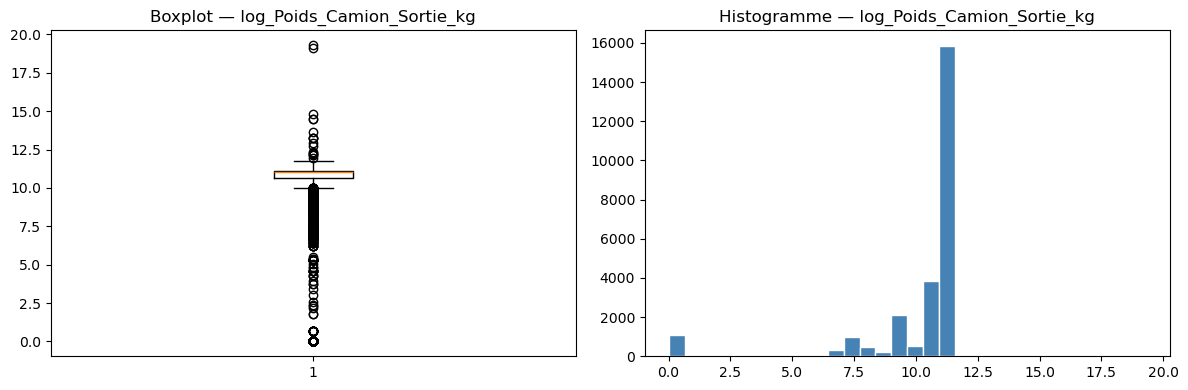

In [17]:
# Application de l'analyse aux variables quantitatives
for var in var_quanti:
    uniquan(var, train)

### Analyse univariée des variables qualitatives

In [18]:
# Fonction pour l'analyse univariée des variables qualitatives
def uniquali(var, df):
    print(var)
    eff = df[var].value_counts()
    print(eff)
    print(df[var].value_counts(normalize=True))
    
    plt.bar(eff.index, eff)
    plt.title(f"Distribution de {var}")
    plt.show()


Nom_Cargaison
Nom_Cargaison
Fertilizer            11487
Vehicle                5278
Wheat                  1695
Steel Bar              1580
Steel Coil             1508
steel sheet            1218
Steel Billet           1030
General Cargo           704
Wire rod                170
Spare Part for Veh      163
Steel Pipe              132
*Rebar                  113
Rice                    113
Steel Structure         108
Steel                    75
Wheat Flour              36
*Sugar                   34
Steel Plate              16
STEEL TUBE               12
I-beam                   12
*Iron                     8
empty bags                4
Steel Rail                1
Yellow Split Peas         1
Name: count, dtype: int64
Nom_Cargaison
Fertilizer            0.450506
Vehicle               0.206997
Wheat                 0.066476
Steel Bar             0.061966
Steel Coil            0.059142
steel sheet           0.047768
Steel Billet          0.040395
General Cargo         0.027610
Wire rod    

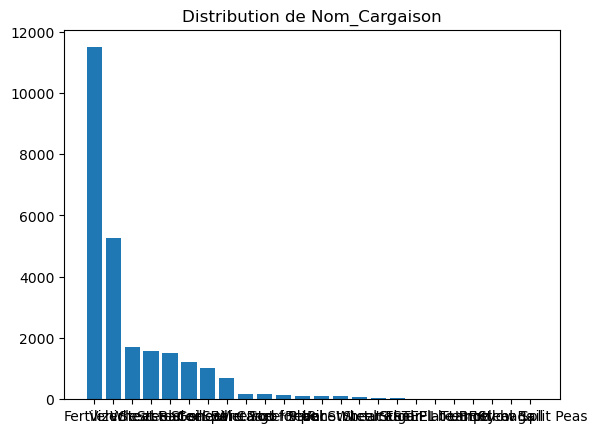

Nom_Navire
Nom_Navire
SABAEK               1796
AFEA                 1554
ZURICH               1392
CORINNA              1346
PANAMAX CHRISTINA    1288
                     ... 
HEILAN CRUISER          1
AGIA FILOTHEI           1
TOSCA                   1
LARUS                   1
HOEGH TARGET            1
Name: count, Length: 120, dtype: int64
Nom_Navire
SABAEK               0.070437
AFEA                 0.060946
ZURICH               0.054593
CORINNA              0.052788
PANAMAX CHRISTINA    0.050514
                       ...   
HEILAN CRUISER       0.000039
AGIA FILOTHEI        0.000039
TOSCA                0.000039
LARUS                0.000039
HOEGH TARGET         0.000039
Name: proportion, Length: 120, dtype: float64


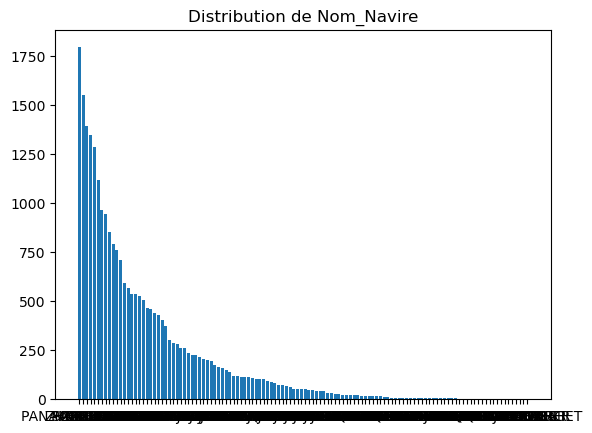

Operateur_Entree
Operateur_Entree
AHMED MOHAMED KASSIM            5542
AHMED.ELMI                      5461
KASSIM.MOHAMED                  3078
BOURHAN.MOHAMED                 1466
HASSAN SAID MOHAMOUD             956
HOUSSEIN.MOHAMED                 862
BADOUL.MOHAMED                   858
APTIDON.SAID                     710
BAYOUMI.WAHIB                    677
YOUSSOUF.MOHAMED                 672
FARAH.ALI                        575
SAMATAR.ABDI                     510
AHMED.ALI                        370
ABDOURAHMAN ALI HASSAN           360
MAHDI.ABDI                       283
ABDOULKADER.MOHAMED              276
AWALEH MAHAMOUD BARREH           266
MIGANEH.SOULEIMAN                235
IBRAHIM.ADEN                     215
ABOUBAKER.HOUSSEIN               207
NASSER.ALI                       189
ABDOULAZIZ.MOHAMED               186
MOUSTAPHA ADEN HADJI-DJIBRIL     179
SAAD.MOHAMED                     179
HOUSSEIN.SOULEIMAN               176
YAHYA.BOROUD                     164
MIGU

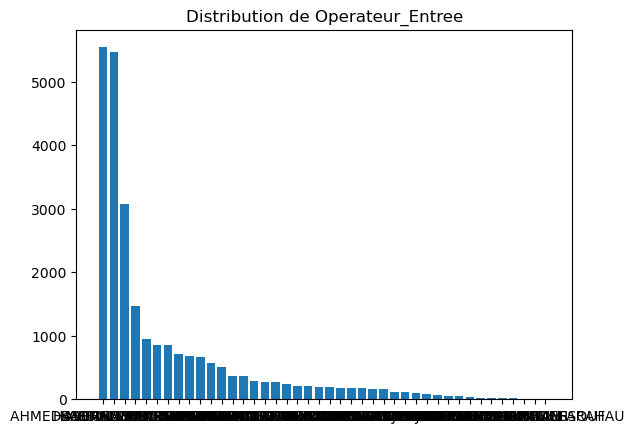

Operateur_Sortie
Operateur_Sortie
OMAR.YOUSSOUF                   4963
SOULEIMAN.LADIEH                4565
AWALEH.IBRAHIM                  4279
MOUSTAPHA ADEN HADJI-DJIBRIL    1372
MOHAMED.ABASS                   1124
YOUSSOUF.MOHAMED                1039
HOUSSEIN.MOHAMED                 991
BADOUL.MOHAMED                   792
MAWLID.YACIN                     649
APTIDON.SAID                     645
AHMED.ALI                        599
AHMED.IBRAHIM                    489
SAAD.MOHAMED                     464
MIGUIL.ALI                       439
IBRAHIM.ADEN                     371
ABDOURAHMAN ALI HASSAN           330
ABDOULAZIZ.MOHAMED               322
AWALEH MAHAMOUD BARREH           284
IBRAHIM SAID MOHAMED             223
ABDOURAZAK.ABDILLAHI             220
HOUSSEIN.SOULEIMAN               210
ABOUBAKER.HOUSSEIN               208
NASSER.ALI                       206
LOUBAK.AHMED                     150
ABDOURAHMAN.FALI                 150
YACOUB.MOHAMED                    90
HASS

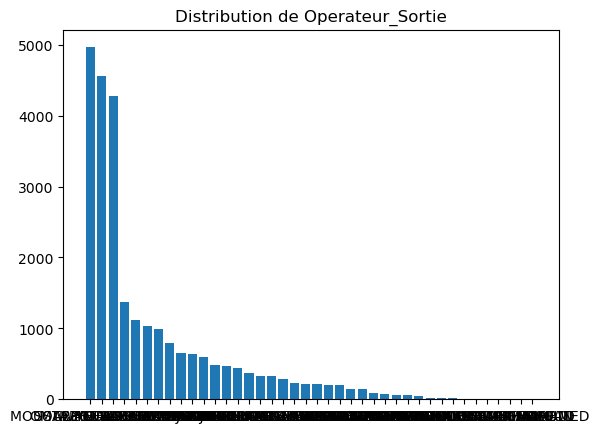

Type_Travail
Type_Travail
Direct Discharge    13369
Delivery            11029
Receiving            1100
Name: count, dtype: int64
Type_Travail
Direct Discharge    0.524316
Delivery            0.432544
Receiving           0.043141
Name: proportion, dtype: float64


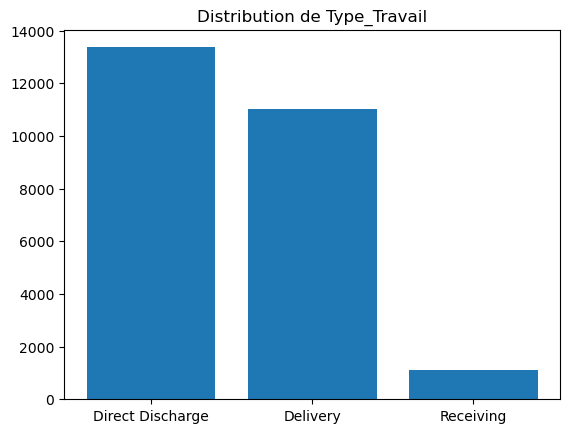

In [19]:
# Application aux variables qualitatives
for var in var_quali:
    uniquali(var, train)


### Analyse bivariée des variables qualitatives & quantitatives 


### Rapport de corrélation
#### Qualitative – Quantitative

In [20]:
def rap_cor(quali, quanti): #fonction qui calcule un rapport de corrélation entre une var quali et une var quanti
    #quali : variable qualitative
    #quanti, var quantitative
    #moyenne par variable
    ybar=quanti.mean()
    
    #SST : variabilité totale = nbre d'ind*variance
    SST=quanti.shape[0]*quanti.var(ddof=0)
    
    #Calcul du SSE
    #DataFrame conditionnellement aux groupes
    Xb=quanti.groupby(quali)
    #effectifs conditionnels
    nk=Xb.size()
    #moyennes conditionnelles dans chaque groupe
    yk=Xb.mean()
    #pour chaque groupe écart à la moyenne par variable
    EMk=(yk-ybar)**2
    #pondéré par les effectifs du groupe
    EM=EMk.multiply(nk,axis=0)
    #somme des valeurs=>BSS
    SSE=np.sum(EM,axis=0)
    
    #Calcul du rapport de corrélation
    nu=SSE/SST
    
    return nu
    

In [21]:
rap_cor(train['Type_Travail'], train['Surestarie_min'])

np.float64(0.006858993414010934)

Le rapport de corrélation mesure la part de la variabilité de la variable quantitative expliquée par la variable qualitative.

### Tous les rapports de corrélation
#### Qualitatives – Quantitatives

In [23]:
def rapport_corr(donnees_quali, donnees_quanti):
    # liste des variables
    listevarquali = donnees_quali.columns
    nbre_quali = donnees_quali.shape[1]
    listevarquanti = donnees_quanti.columns
    nbre_quanti = donnees_quanti.shape[1]

    # préparation du DataFrame résultat
    nuligne = pd.DataFrame(columns=["rap_corr", "nom1", "nom2"], 
                           index=range(0, nbre_quali * nbre_quanti))

    # calcul des coefficients
    val = 0
    for i in range(nbre_quali):
        
        for j in range(nbre_quanti):
            nuligne.loc[val, "rap_corr"] = rap_cor(donnees_quali.iloc[:, i], donnees_quanti.iloc[:, j])
            nuligne.loc[val, "nom1"] = listevarquali[i]
            nuligne.loc[val, "nom2"] = listevarquanti[j]
            val += 1

    # tri décroissant
    nuge = nuligne.sort_values(by="rap_corr", ascending=False)
        
    return(nuge)

#### Corrélation
#### Quantitative – Quantitative

In [24]:
def coef_corr(X):
    #X : un dataframe qui ne contient que des variables quantitatives
    matcor=X.corr() 
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(matcor, annot=True, cmap="coolwarm", center=0)
    plt.show()
    sns.clustermap(matcor, cmap="coolwarm", center=0)
    plt.show()

    #nbre de variables à traiter
    nbrevarexp=X.shape[1]
    #nom des variables
    listevarexp=X.columns
    #préparation du dataframe qui contiendra : les coefficients de corrélation, la valeur absolue de ce coef et les noms des deux variables considérées
    corrligne=pd.DataFrame(columns=["corr","abscorr","nom1","nom2"],index=range(0,nbrevarexp*(nbrevarexp-1)//2))
    #calcul de tous les coefficients nécessaires (matrice symétrique)
    val=0
    for i in range(0,nbrevarexp-1):
        for j in range(i+1,nbrevarexp):
            corrligne["corr"][val]=matcor[listevarexp[i]][listevarexp[j]]
            corrligne["abscorr"][val]=abs(matcor[listevarexp[i]][listevarexp[j]])
            corrligne["nom1"][val]=listevarexp[i]
            corrligne["nom2"][val]=listevarexp[j]
            val+=1
    #trie des valeurs de facon décroissante
    corr=corrligne.sort_values(by="abscorr",ascending=False)
    return(corr)

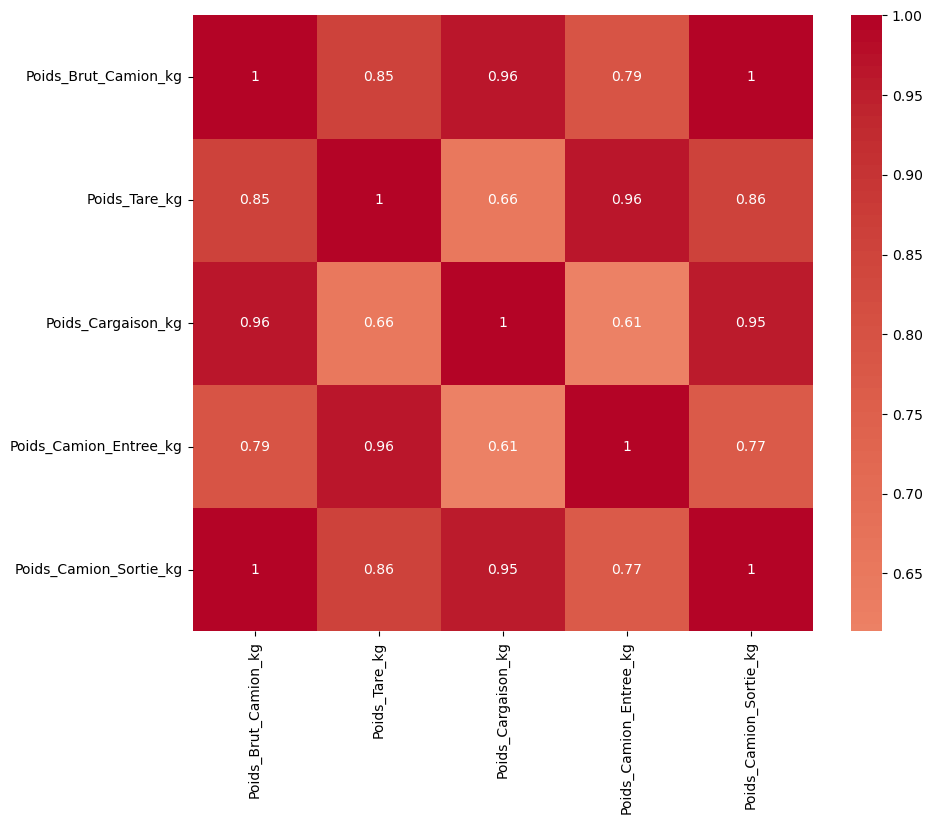

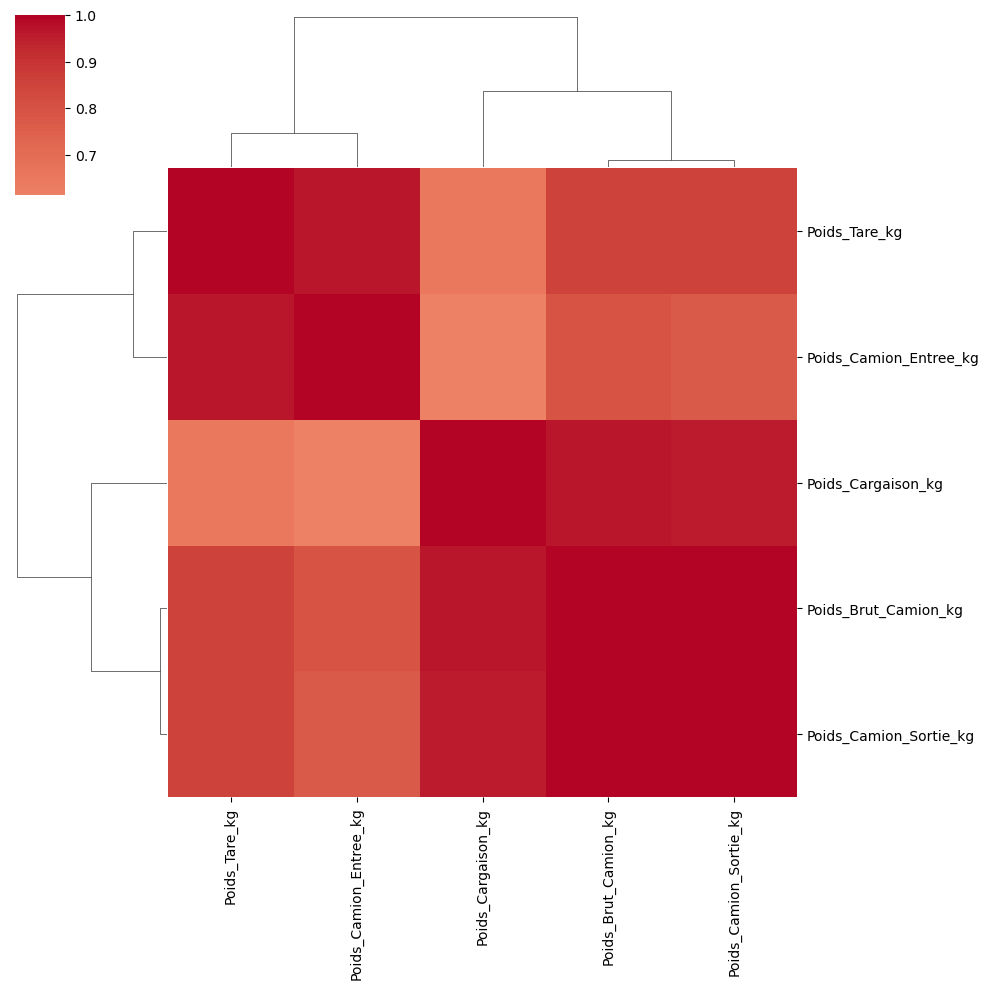

In [27]:
# ===============================
# Variables quantitatives
# (Surestarie_min est exclue car c'est la variable cible)
# ===============================
# Variables quantitatives présentes dans train
var_quanti = [
    'Poids_Brut_Camion_kg', 'Poids_Tare_kg',
    'Poids_Cargaison_kg', 'Poids_Camion_Entree_kg',
    'Poids_Camion_Sortie_kg'
]
# sans Surestarie_min qui est la variable à prédire
# corrélations quanti/quanti
matcor = train[var_quanti].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matcor, annot=True, cmap="coolwarm", center=0)
plt.show()
sns.clustermap(matcor, cmap="coolwarm", center=0)
plt.show()

La matrice de corrélation permet d’identifier les relations linéaires entre les variables quantitatives.
Le clustermap met en évidence des groupes de variables fortement corrélées, ce qui aide à détecter la redondance et à réduire la multicolinéarité avant la modélisation.

In [34]:
# Solution : supprimer les variables redondantes
# Poids_Brut_Camion_kg ≈ Poids_Camion_Sortie_kg → garder une seule
# Suppression de la variable redondante uniquement si elle existe
if 'Poids_Brut_Camion_kg' in train.columns:
    train = train.drop(columns=['Poids_Brut_Camion_kg'])



#### Association
### Qualitative – Qualitative

In [28]:
import scipy.stats as ss
def cramers(x,y):
    #x,y : vecteurs contenant chacun une variable qualitative
    
    #tableau de contingence
    contingence_matrix = pd.crosstab(x,y)
    #chi2 entre les deux variables
    chi2 = ss.chi2_contingency(contingence_matrix)[0]
    #nbre total d'individus
    n = contingence_matrix.sum().sum()
    #nbre de modalités de chaque variable
    r,k = contingence_matrix.shape
    m=min(r-1,k-1)
    #calcul du V de Cramers
    return np.sqrt((chi2/(n*m)))

In [29]:
def coef_cramer(X):
    nbrevarexp = X.shape[1]
    # noms des variables
    listevarexp = X.columns
    
    # préparation du dataframe résultat
    corrligne = pd.DataFrame(columns=["V_cramer", "nom1", "nom2"], 
                             index=range(0, nbrevarexp * (nbrevarexp - 1) // 2))
    
    # calcul des coefficients
    val = 0
    for i in range(0, nbrevarexp - 1):
        for j in range(i + 1, nbrevarexp):
            corrligne.loc[val, "V_cramer"] = cramers(X.iloc[:, i], X.iloc[:, j])
            corrligne.loc[val, "nom1"] = listevarexp[i]
            corrligne.loc[val, "nom2"] = listevarexp[j]
            val += 1
    
    # tri décroissant
    corr = corrligne.sort_values(by="V_cramer", ascending=False)
    return corr


In [35]:
#var quali entre elles
coef_cramer(train[var_quali])

,V_cramer,nom1,nom2
6,0.992796,Nom_Navire,Type_Travail
3,0.750605,Nom_Cargaison,Type_Travail
0,0.634831,Nom_Cargaison,Nom_Navire
9,0.543769,Operateur_Sortie,Type_Travail
8,0.424192,Operateur_Entree,Type_Travail
7,0.357226,Operateur_Entree,Operateur_Sortie
4,0.295712,Nom_Navire,Operateur_Entree
5,0.291848,Nom_Navire,Operateur_Sortie
2,0.224036,Nom_Cargaison,Operateur_Sortie
1,0.221868,Nom_Cargaison,Operateur_Entree
